# MODULE 1: Data Collection & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Loan Prediction Dataset.csv')
df = df.drop('Loan_ID', axis=1)
print(df.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


Categorical fields: fill missing values with the most frequent category (mode)

In [3]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0]).astype(int)
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


Median was used instead of mean to fill missing LoanAmount values, as loan
amounts in the dataset are right-skewed with some high-value outliers,
making median a more robust and representative measure of central tendency.

Encode binary categorical variables as 0/1 for correlation analysis and modeling

In [4]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

Treat "3+" as 3 (floor value) so Dependents can be used as a numeric feature

In [5]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nPreview:\n", df.head())

Missing values:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Data types:
 Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int64
Property_Area         object
Loan_Status            int64
dtype: object

Preview:
    Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0             5849   
1       1        1           1          1              0             4583   
2       1        1           0          1              1             3000   

#MODULE 2: Exploratory Data Analysis

### Customer Income Patterns

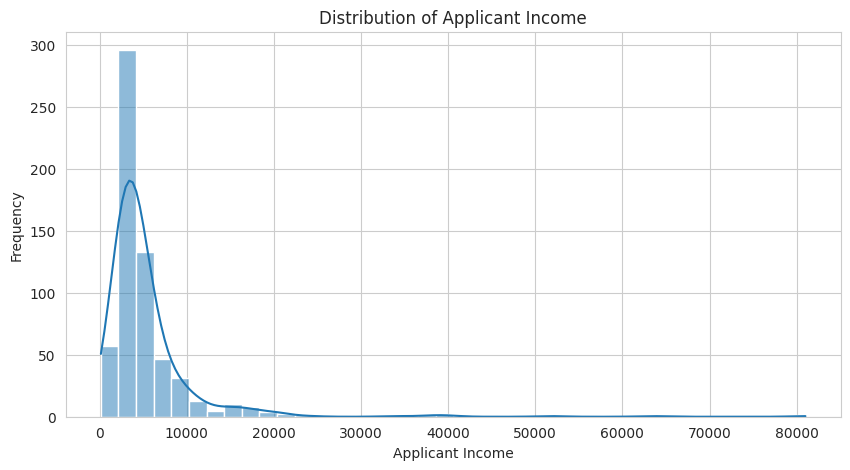

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
sns.histplot(df['ApplicantIncome'], bins=40, kde=True)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

Income is right-skewed (most people cluster at lower income, with a few very high earners stretching the tail)

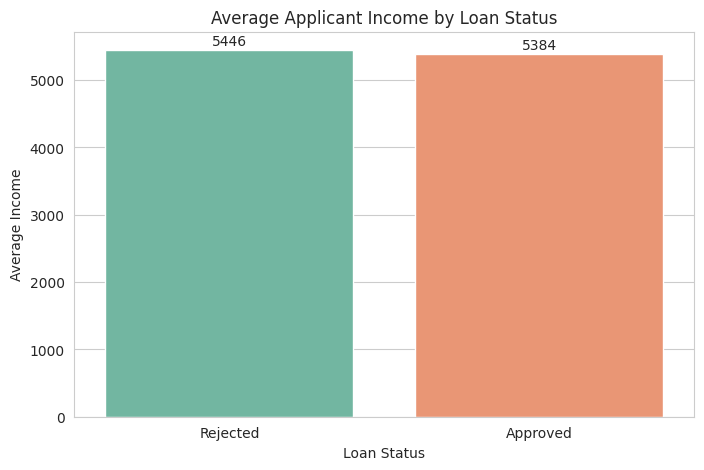

In [8]:
avg_income = df.groupby('Loan_Status')['ApplicantIncome'].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(x='Loan_Status', y='ApplicantIncome', data=avg_income, hue='Loan_Status', palette='Set2', legend=False)
plt.title('Average Applicant Income by Loan Status')
plt.xlabel('Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.ylabel('Average Income')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1)
plt.show()


Average applicant income is nearly identical between rejected (₹5,446) and approved
(₹5,384) applicants — a difference of just ₹62. This confirms that income alone is a
weak predictor of loan approval, consistent with its near-zero correlation with
Loan Status seen later in the heatmap. This is a somewhat counterintuitive finding:
approval appears driven far more by creditworthiness than by how much an applicant earns.

Combining applicant + coapplicant income into household income — often a stronger
predictor than individual income alone

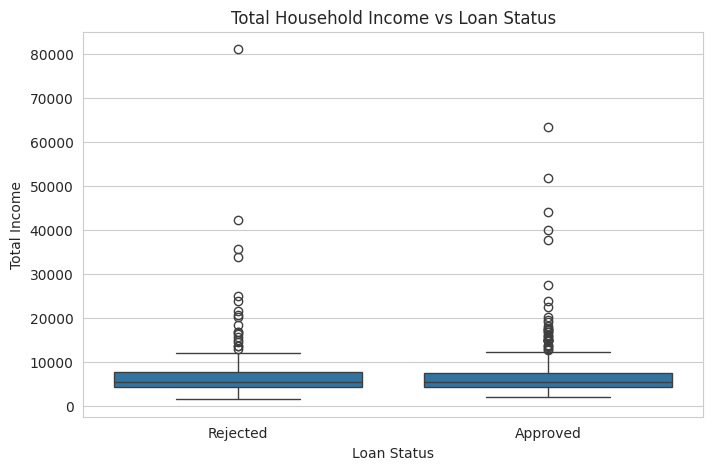

In [9]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='Total_Income', data=df)
plt.title('Total Household Income vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Total Income')
plt.xticks([1, 0], ['Approved', 'Rejected'])
plt.show()

Total household income shows nearly identical distributions between Rejected and
Approved applicants — similar median, spread, and outlier patterns in both groups.
This confirms that total income alone does not meaningfully separate approved from
rejected applicants, reinforcing that approval decisions are driven more by
creditworthiness (Credit_History) than by income level.

## Loan amounts

Distribution of loan amounts

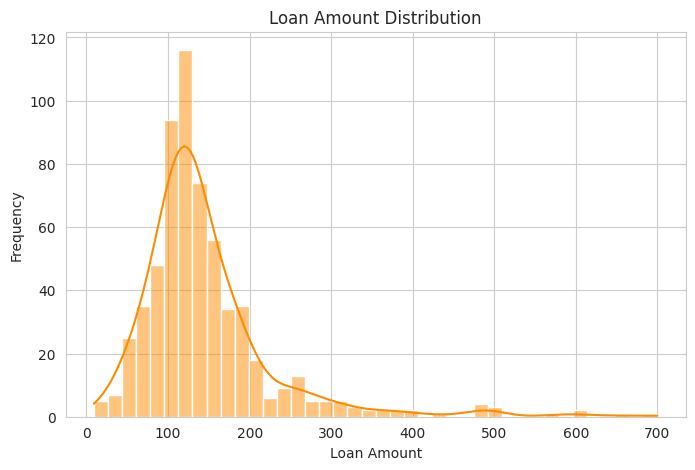

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=40, kde=True, color='darkorange')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

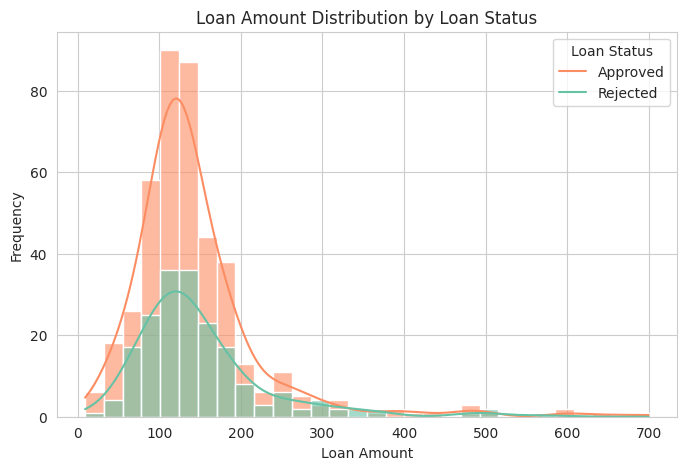

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='LoanAmount', hue='Loan_Status', bins=30, kde=True, palette='Set2', alpha=0.6)
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.legend(title='Loan Status', labels=['Approved', 'Rejected'])
plt.show()

The loan amount distributions for approved and rejected applicants are nearly
identical in shape, both peaking around ₹100-200 with a similar right-skewed tail.
This visual overlap reinforces that loan amount alone does not strongly differentiate
approved from rejected applicants — consistent with its near-zero correlation with
Loan_Status.

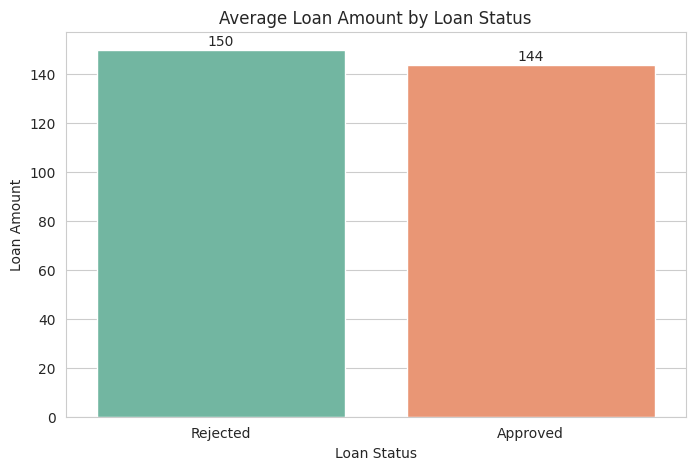

In [12]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Loan_Status', y='LoanAmount', data=df, hue='Loan_Status', palette='Set2', errorbar=None, legend=False)
plt.title('Average Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.ylabel('Loan Amount')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1)
plt.show()

Average loan amount is nearly identical between rejected (150) and approved (144)
applicants, confirming the pattern seen in the distribution chart above — loan
amount alone does not meaningfully predict approval outcome.

## Credit History

Count of good vs bad credit history

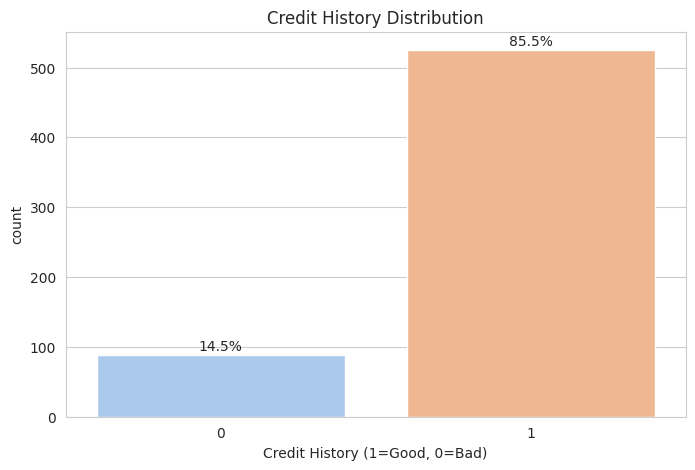

In [13]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x=df['Credit_History'].astype(int), hue=df['Credit_History'].astype(int), palette='pastel', legend=False)
plt.title('Credit History Distribution')
plt.xlabel('Credit History (1=Good, 0=Bad)')
total = len(df)
for container in ax.containers:
    labels = [f'{(v.get_height()/total)*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=1)
plt.show()

The majority of applicants (~86%) have good credit history, while ~14% have poor
credit history — a realistic, imbalanced real-world lending population.

Credit history vs loan approval — THE key chart

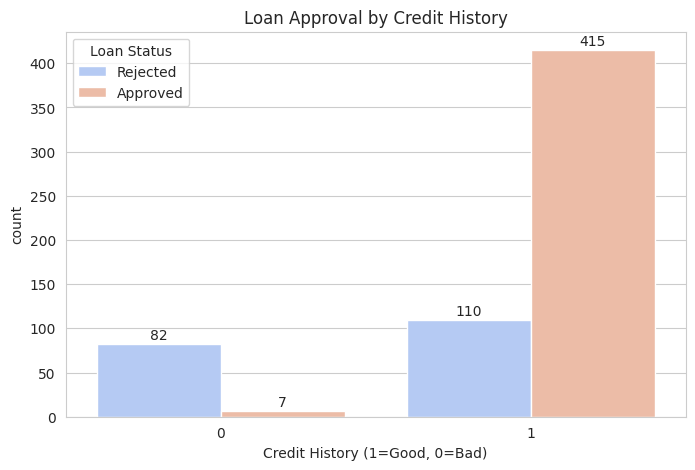

In [14]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='coolwarm')
plt.title('Loan Approval by Credit History')
plt.xlabel('Credit History (1=Good, 0=Bad)')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1)
plt.show()

Applicants with good credit history are approved at a dramatically higher rate than
those with poor credit history, confirming Credit History as the dominant predictor
— consistent with its 0.54 correlation with Loan Status seen later in the heatmap.

## Default trends

Overall approval vs rejection rate

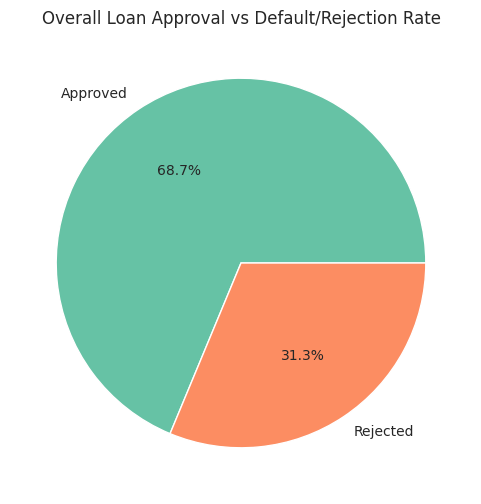

In [15]:
plt.figure(figsize=(6,6))
df['Loan_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                        labels=['Approved', 'Rejected'],
                                        colors=sns.color_palette('Set2'))
plt.title('Overall Loan Approval vs Default/Rejection Rate')
plt.ylabel('')
plt.show()

~68.7% of applicants were approved overall. This baseline is important context:
a model predicting "Approved" for everyone would already show ~69% accuracy, so
precision/recall/F1 (not accuracy alone) are used to properly evaluate model performance.

Default trend by Education

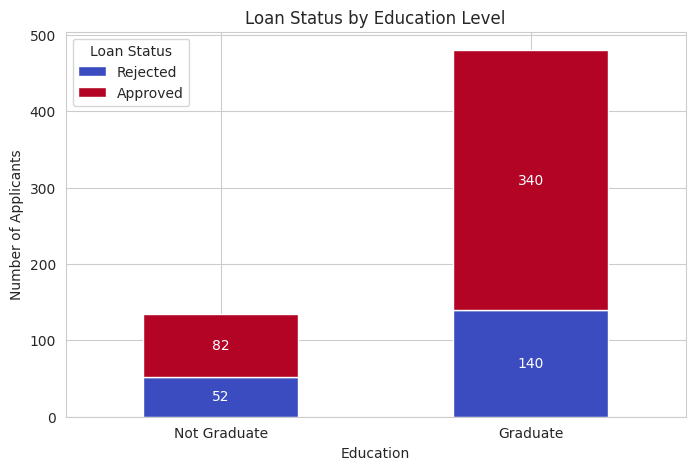

In [16]:
ax = pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', stacked=True,
                                                        colormap='coolwarm', figsize=(8,5))
plt.title('Loan Status by Education Level')
plt.xlabel('Education')
plt.ylabel('Number of Applicants')
plt.xticks([0, 1], ['Not Graduate', 'Graduate'], rotation=0)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f',label_type='center', color='white')
plt.show()

Education level shows a meaningful influence on loan outcomes — Graduate applicants
are approved noticeably more often than Not Graduate applicants. This contrasts with
income and loan amount, which showed little to no relationship with approval,
suggesting that qualitative factors like education and credit history carry more
weight in the approval decision than raw financial figures.

Default trend by Marital Status

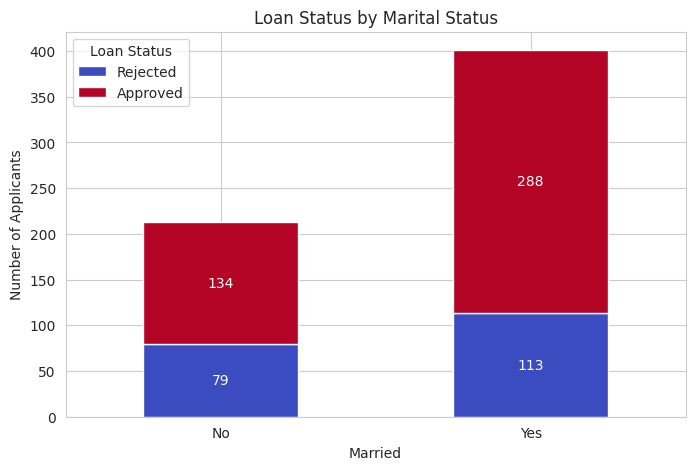

In [17]:
ax = pd.crosstab(df['Married'], df['Loan_Status']).plot(kind='bar', stacked=True,
                                                      colormap='coolwarm', figsize=(8,5))
plt.title('Loan Status by Marital Status')
plt.xlabel('Married')
plt.ylabel('Number of Applicants')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f',label_type='center', color='white')
plt.show()

Married applicants show a higher approval rate than unmarried applicants, possibly
reflecting perceived financial stability associated with dual-income households —
though as with education, this effect is far smaller than the dominant impact of
Credit History.

Gender, Self-Employment status, and Dependents were also examined but showed negligible variation in approval rates and are omitted here for brevity.

## Risk distribution

Risk distribution across property area

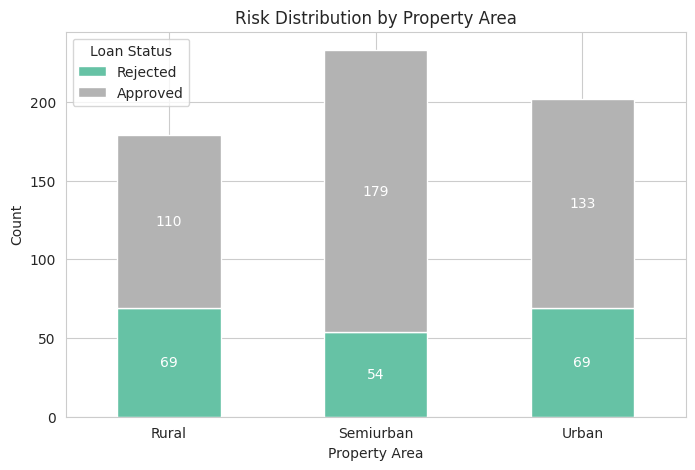

In [18]:
ax = pd.crosstab(df['Property_Area'], df['Loan_Status']).plot(kind='bar', stacked=True,
                                                            colormap='Set2', figsize=(8,5))
plt.title('Risk Distribution by Property Area')
plt.xlabel('Property Area')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f',label_type='center', color='white')
plt.show()

Semiurban applicants show the highest approval rate, while Rural applicants show the
lowest — a modest regional effect, far smaller than the impact of Credit History.

Overall correlation heatmap (whole-dataset risk factor overview)

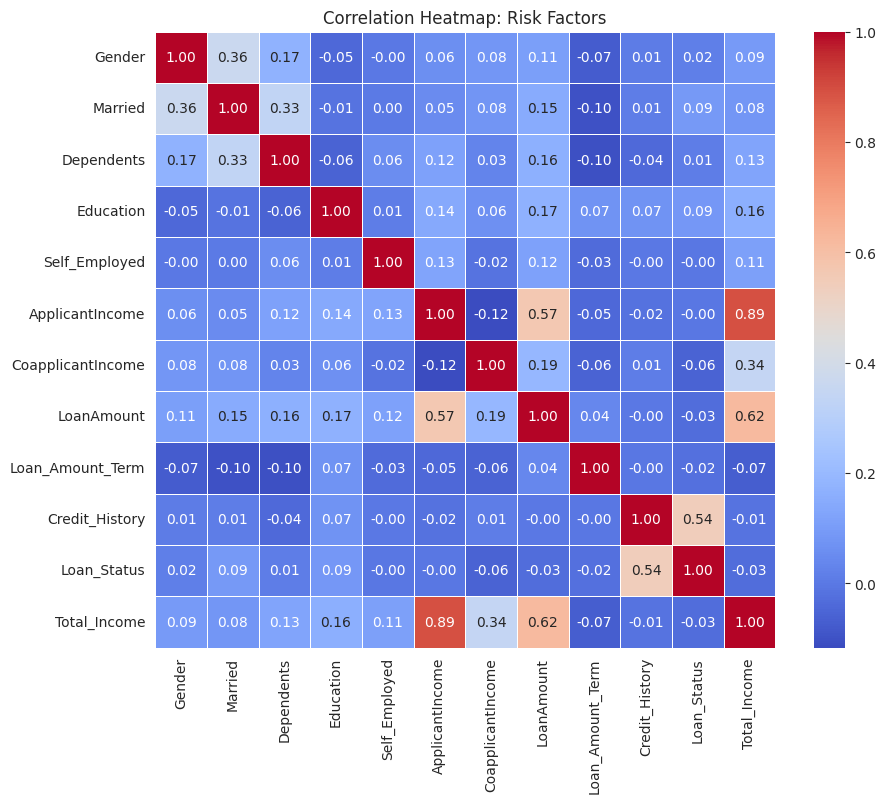

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Risk Factors')
plt.show()

Correlation heatmap: Credit_History (0.54) is by far the strongest risk factor;
income, loan amount, and demographics show weak/negligible correlation with Loan Status.

# Module 3: Credit Risk Prediction Model

One-hot encode Property_Area (nominal, no natural order) and prepare train/test split
Scale features so distance/gradient-based models (Logistic Regression) aren't skewed by feature magnitude

In [20]:
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_classifier.fit(x_train, y_train)
y_pred_dt = dt_classifier.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print(" Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=['Rejected', 'Approved']))

 Decision Tree Results
Accuracy: 0.7337662337662337
Precision: 0.8301886792452831
Recall: 0.7927927927927928
F1 Score: 0.8110599078341014

Confusion Matrix:
 [[25 18]
 [23 88]]

Classification Report:

              precision    recall  f1-score   support

    Rejected       0.52      0.58      0.55        43
    Approved       0.83      0.79      0.81       111

    accuracy                           0.73       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.74      0.73      0.74       154



## Random forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=0)
rf_classifier.fit(x_train, y_train)
y_pred_rf = rf_classifier.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print(" Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Rejected', 'Approved']))

 Random Forest Results
Accuracy: 0.7987012987012987
Precision: 0.8448275862068966
Recall: 0.8828828828828829
F1 Score: 0.8634361233480177

Confusion Matrix:
 [[25 18]
 [13 98]]

Classification Report:

              precision    recall  f1-score   support

    Rejected       0.66      0.58      0.62        43
    Approved       0.84      0.88      0.86       111

    accuracy                           0.80       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.79      0.80      0.79       154



## Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log, target_names=['Rejected', 'Approved']))

Logistic Regression Results
Accuracy: 0.8376623376623377
Precision: 0.8257575757575758
Recall: 0.9819819819819819
F1 Score: 0.897119341563786

Confusion Matrix:
 [[ 20  23]
 [  2 109]]

Classification Report:

              precision    recall  f1-score   support

    Rejected       0.91      0.47      0.62        43
    Approved       0.83      0.98      0.90       111

    accuracy                           0.84       154
   macro avg       0.87      0.72      0.76       154
weighted avg       0.85      0.84      0.82       154



In [24]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_log)],

    'Precision': [precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_log)],

    'Recall': [recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_log)],


    'F1-score': [f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_log)]
})

print(results)

print("\nConfusion Matrix Comparison\n")

print("Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))
print()

print("Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print()

print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_log))

                 Model  Accuracy  Precision    Recall  F1-score
0        Decision Tree  0.733766   0.830189  0.792793  0.811060
1        Random Forest  0.798701   0.844828  0.882883  0.863436
2  Logistic Regression  0.837662   0.825758  0.981982  0.897119

Confusion Matrix Comparison

Decision Tree:
[[25 18]
 [23 88]]

Random Forest:
[[25 18]
 [13 98]]

Logistic Regression:
[[ 20  23]
 [  2 109]]


"While Logistic Regression achieved the highest overall accuracy (83.8%) and F1-score (89.7%), closer inspection of the confusion matrix reveals a critical weakness: it correctly identifies only 47% of actually risky (Rejected) applicants, meaning it would approve many loans that should be rejected — a serious flaw for a credit risk system. Random Forest, despite slightly lower overall accuracy (79.9%), correctly identifies 58% of risky applicants, making it the more suitable choice for minimizing financial risk exposure, even at the cost of a few more false rejections of creditworthy applicants."

In [25]:
import joblib

joblib.dump(rf_classifier, 'loan_model.pkl')
joblib.dump(sc, 'scaler.pkl')

['scaler.pkl']